In [423]:
import sys
import os
import warnings
from datetime import datetime, timezone, timedelta
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
import json
from zoneinfo import ZoneInfo
from pandas import Timestamp
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from scipy.stats import norm

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.insert(0, str(parent_dir))
from lib import *

MODEL_PATH=parent_dir / 'models' 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [424]:
example_ticker = "KXBTC15M-26MAY040515-15"
lookback_minutes = 10000
series, event_dt = parse_kalshi_15m_event_ticker(example_ticker)
dt_only = get_ticker_datetime(example_ticker)
# crypto_at = datetime(2026,5,5,0,0,tzinfo=ZoneInfo('America/Chicago'))
crypto_at = datetime.now(tz=ZoneInfo('America/Chicago'))
df_api = get_market_data_from_api(series, crypto_at, lookback_minutes)
df_api = df_api.set_index('datetime')
df_api.head()

Error getting market candlesticks: 'floor_strike'
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY140215-15/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY140215-15&start_ts=1778738100&end_ts=1778739300&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY140230-30/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY140230-30&start_ts=1778739000&end_ts=1778740200&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not foun

,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar
datetime,,,,,,,,,,,,,,,,,,,,
2026-05-10 09:46:00-05:00,KXBTC15M-26MAY101100-00,80891.93,12890.34,10443.63,0.84,0.84,0.51,0.51,0.00,0.61,0.00,0.50,0.50,0.39,1.00,1.00,0.49,0.16,0.49,0.16
2026-05-10 09:47:00-05:00,KXBTC15M-26MAY101100-00,80891.93,29318.08,29294.61,0.51,0.51,0.36,0.36,0.50,0.50,0.35,0.35,0.65,0.50,0.65,0.50,0.64,0.49,0.64,0.49
2026-05-10 09:48:00-05:00,KXBTC15M-26MAY101100-00,80891.93,40570.46,52410.16,0.36,0.36,0.14,0.16,0.35,0.35,0.13,0.15,0.85,0.65,0.87,0.65,0.84,0.64,0.86,0.64
2026-05-10 09:49:00-05:00,KXBTC15M-26MAY101100-00,80891.93,25617.68,64450.46,0.16,0.23,0.13,0.21,0.15,0.22,0.12,0.20,0.80,0.78,0.88,0.85,0.79,0.77,0.87,0.84
2026-05-10 09:50:00-05:00,KXBTC15M-26MAY101100-00,80891.93,18856.24,77721.42,0.21,0.21,0.14,0.15,0.20,0.20,0.13,0.14,0.86,0.80,0.87,0.80,0.85,0.79,0.86,0.79


In [425]:
df_crypto = get_crypto_past_minutes(series, crypto_at, lookback_minutes)
df_crypto['datetime'] = pd.to_datetime(df_crypto['datetime'])
df_crypto['datetime'] = df_crypto['datetime'].dt.tz_convert('America/Chicago')
df_crypto['datetime'] = df_crypto['datetime'].dt.floor('min')
df_crypto = df_crypto.set_index('datetime')
filter_timestamp = df_crypto[df_crypto.index.minute.isin([0,15,30,45])].index[0]
df_crypto = df_crypto[df_crypto.index >= filter_timestamp]
df_crypto.head()

,open,high,low,close,tick_count
datetime,,,,,
2026-05-05 17:15:00-05:00,81376.20,81379.97,81376.20,81379.97,0
2026-05-05 17:16:00-05:00,81399.56,81399.56,81399.56,81399.56,0
2026-05-05 17:17:00-05:00,81367.29,81367.29,81350.41,81350.48,25
2026-05-05 17:18:00-05:00,81359.07,81359.07,81359.07,81359.07,0
2026-05-05 17:19:00-05:00,81357.06,81357.07,81357.06,81357.07,0


In [426]:
df_merged = df_crypto.join(df_api, how='left')
df_merged = df_merged.dropna()
df_merged.head()

,open,high,low,close,tick_count,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-10 09:46:00-05:00,80892.85,80901.57,80892.65,80899.93,32,KXBTC15M-26MAY101100-00,80891.93,12890.34,10443.63,0.84,0.84,0.51,0.51,0.00,0.61,0.00,0.50,0.50,0.39,1.00,1.00,0.49,0.16,0.49,0.16
2026-05-10 09:47:00-05:00,80893.38,80893.38,80893.38,80893.38,0,KXBTC15M-26MAY101100-00,80891.93,29318.08,29294.61,0.51,0.51,0.36,0.36,0.50,0.50,0.35,0.35,0.65,0.50,0.65,0.50,0.64,0.49,0.64,0.49
2026-05-10 09:48:00-05:00,80884.89,80884.89,80884.89,80884.89,0,KXBTC15M-26MAY101100-00,80891.93,40570.46,52410.16,0.36,0.36,0.14,0.16,0.35,0.35,0.13,0.15,0.85,0.65,0.87,0.65,0.84,0.64,0.86,0.64
2026-05-10 09:49:00-05:00,80838.37,80838.37,80838.37,80838.37,0,KXBTC15M-26MAY101100-00,80891.93,25617.68,64450.46,0.16,0.23,0.13,0.21,0.15,0.22,0.12,0.20,0.80,0.78,0.88,0.85,0.79,0.77,0.87,0.84
2026-05-10 09:50:00-05:00,80833.33,80833.44,80825.03,80828.52,33,KXBTC15M-26MAY101100-00,80891.93,18856.24,77721.42,0.21,0.21,0.14,0.15,0.20,0.20,0.13,0.14,0.86,0.80,0.87,0.80,0.85,0.79,0.86,0.79


In [455]:
df_calc = df_merged

In [456]:
research_side = 'no'
df_calc[research_side + '_dist'] = df_calc['close'] - df_calc['floor_strike']
df_calc['log_return'] = np.log(df_calc['close'] / df_calc['close'].shift(1))
df_calc['m3_log_return'] = df_calc['log_return'].rolling(3).std()
df_calc['m5_log_return'] = df_calc['log_return'].rolling(5).std()
df_calc['ma3'] = df_calc['close'].rolling(3).mean()
df_calc['ma5'] = df_calc['close'].rolling(5).mean()
df_calc['ma3_vs_strike'] = (df_calc['ma3'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['ma5_vs_strike'] = (df_calc['ma5'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc[research_side + '_dist_pct'] = df_calc[research_side + '_dist'] / df_calc['floor_strike'] * 100
df_calc['m1_' + research_side + '_dist_momentum'] = df_calc[research_side + '_dist'] - df_calc[research_side + '_dist'].shift(1)
df_calc['m3_' + research_side + '_dist_momentum'] = df_calc[research_side + '_dist'] - df_calc[research_side + '_dist'].shift(3)
df_calc['m5_' + research_side + '_dist_momentum'] = df_calc[research_side + '_dist'] - df_calc[research_side + '_dist'].shift(5)
df_calc['time_decay'] = np.where(df_calc.index.minute % 15 == 0, 0, 15 - df_calc.index.minute % 15)
df_calc['hour'] = df_calc.index.hour
df_calc['minute'] = df_calc.index.minute
df_calc[research_side + '_spread'] = df_calc[research_side + '_ask_close_dollar'] - df_calc[research_side + '_bid_close_dollar']
df_calc['volume_surge'] = df_calc['volume_fp'] / df_calc['volume_fp'].rolling(5).mean()
df_calc['oi_change'] = df_calc['open_interest_fp'] - df_calc['open_interest_fp'].shift(1)

In [457]:
df_calc = df_calc.dropna()

In [458]:
df_calc.head()

,open,high,low,close,tick_count,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar,yes_dist,log_return,m3_log_return,m5_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,m1_yes_dist_momentum,m3_yes_dist_momentum,m5_yes_dist_momentum,time_decay,hour,minute,yes_spread,volume_surge,oi_change,no_dist,no_dist_pct,m1_no_dist_momentum,m3_no_dist_momentum,m5_no_dist_momentum,no_spread
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-10 09:51:00-05:00,80828.02,80828.02,80828.02,80828.02,0,KXBTC15M-26MAY101100-00,80891.93,49018.46,78094.43,0.150,0.660,0.150,0.570,0.140,0.650,0.14,0.560,0.440,0.350,0.86,0.860,0.430,0.340,0.850,0.850,-63.91,-0.000006,0.000301,0.000227,80831.636667,80854.636,-0.074536,-0.046103,-0.079007,-0.50,-56.87,-71.91,9,9,51,0.010,1.500128,373.01,-63.91,-0.079007,-0.50,-56.87,-71.91,0.010
2026-05-10 09:52:00-05:00,80901.39,80903.52,80894.80,80896.89,16,KXBTC15M-26MAY101100-00,80891.93,36344.11,61009.14,0.570,0.770,0.470,0.720,0.560,0.760,0.46,0.710,0.290,0.240,0.54,0.440,0.280,0.230,0.530,0.430,4.96,0.000852,0.000532,0.000520,80851.143333,80855.338,-0.050421,-0.045236,0.006132,68.87,58.52,3.51,8,9,52,0.010,1.066392,-17085.29,4.96,0.006132,68.87,58.52,3.51,0.010
2026-05-10 09:53:00-05:00,80928.17,80928.22,80911.12,80912.89,25,KXBTC15M-26MAY101100-00,80891.93,38584.69,53419.46,0.720,0.820,0.640,0.790,0.710,0.810,0.61,0.780,0.220,0.190,0.39,0.290,0.210,0.180,0.360,0.280,20.96,0.000198,0.000448,0.000521,80879.266667,80860.938,-0.015655,-0.038313,0.025911,16.00,84.37,28.00,7,9,53,0.010,1.145482,-7589.68,20.96,0.025911,16.00,84.37,28.00,0.010
2026-05-10 09:54:00-05:00,80935.33,80987.35,80928.24,80987.24,39,KXBTC15M-26MAY101100-00,80891.93,45287.12,57111.32,0.790,0.950,0.780,0.935,0.780,0.946,0.75,0.922,0.078,0.054,0.25,0.220,0.065,0.050,0.220,0.210,95.31,0.000918,0.000398,0.000486,80932.340000,80890.712,0.049956,-0.001506,0.117824,74.35,159.22,148.87,6,9,54,0.013,1.203864,3691.86,95.31,0.117824,74.35,159.22,148.87,0.010
2026-05-10 09:55:00-05:00,80941.23,80941.23,80941.23,80941.23,0,KXBTC15M-26MAY101100-00,80891.93,32569.31,68615.66,0.935,0.968,0.927,0.944,0.922,0.963,0.92,0.943,0.057,0.037,0.08,0.078,0.056,0.032,0.073,0.065,49.30,-0.000568,0.000743,0.000621,80947.120000,80913.254,0.068227,0.026361,0.060946,-46.01,44.34,112.71,5,9,55,0.001,0.806955,11504.34,49.30,0.060946,-46.01,44.34,112.71,0.013


In [459]:
def agg_data_function(df, column, *data_cents):
    results = {cent: [] for cent in data_cents}
    triggered = set() 
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        if row['time_decay'] == 0:
            continue
        
        current_ticker = row['ticker']
        
        for cent in data_cents:
            if (current_ticker, cent) in triggered:
                continue
                
            if float(row[column + '_ask_low_dollar']) < float(cent):
                # print(f"trigger: {column + '_ask_low_dollar'}: {row[column + '_ask_low_dollar']}")
                triggered.add((current_ticker, cent)) 
                
                high_price = 0
                low_price = 1
                
                for j in range(1, 16):
                    if i + j >= len(df):
                        break
                    next_row = df.iloc[i + j]
                    high_price = max(next_row[column + '_bid_high_dollar'], high_price)
                    low_price = min(next_row[column + '_ask_low_dollar'], low_price)
                    if next_row['ticker'] != current_ticker or next_row['time_decay'] == 0:
                        break
                
                tmp_dict = row.to_dict()
                tmp_dict['subsequent_high'] = high_price
                tmp_dict['subsequent_low'] = low_price
                tmp_dict['reached_30'] = 1 if high_price >= 0.30 else 0
                tmp_dict['reached_40'] = 1 if high_price >= 0.40 else 0
                tmp_dict['reached_50'] = 1 if high_price >= 0.50 else 0
                tmp_dict['reached_60'] = 1 if high_price >= 0.60 else 0
                tmp_dict['reached_70'] = 1 if high_price >= 0.7 else 0
                tmp_dict['reached_90'] = 1 if high_price >= 0.9 else 0
                results[cent].append(tmp_dict)
                
    
    return results

In [460]:
res=agg_data_function(df_calc, research_side, *[0.05,0.1,0.15,0.2,0.25,0.3,0.35])

In [461]:
# win rate analysis
comb_05 = pd.DataFrame(res[0.05])
comb_10 = pd.DataFrame(res[0.10])
comb_15 = pd.DataFrame(res[0.15])
comb_20 = pd.DataFrame(res[0.2])
comb_25 = pd.DataFrame(res[0.25])
comb_30 = pd.DataFrame(res[0.3])
comb_35 = pd.DataFrame(res[0.35])

In [462]:
comb_10[comb_10['reached_50']==1].head()

,open,high,low,close,tick_count,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar,yes_dist,log_return,m3_log_return,m5_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,m1_yes_dist_momentum,m3_yes_dist_momentum,m5_yes_dist_momentum,time_decay,hour,minute,yes_spread,volume_surge,oi_change,no_dist,no_dist_pct,m1_no_dist_momentum,m3_no_dist_momentum,m5_no_dist_momentum,no_spread,subsequent_high,subsequent_low,reached_30,reached_40,reached_50,reached_60,reached_70,reached_90
22,82047.14,82055.0,82047.14,82055.0,8,KXBTC15M-26MAY111615-15,81950.83,22317.03,135793.68,0.91,0.96,0.909,0.953,0.909,0.955,0.908,0.942,0.058,0.045,0.092,0.091,0.047,0.04,0.091,0.09,104.17,0.000253,0.000296,0.000337,82050.303333,82049.616,0.121382,0.120543,0.127113,20.74,-15.49,25.76,4,15,11,0.011,0.864966,10757.47,104.17,0.127113,20.74,-15.49,25.76,0.001,0.88,0.921,1,1,1,1,1,0


In [463]:
def get_protential_pnl(df, entry_price, *exit_price):
    for price in exit_price:
        col_name = f"reached_{int(price * 100)}"
        if col_name in df.columns:
            rate = (df[col_name] == 1).sum() / len(df)
            pnl = rate * (float(price) - float(entry_price))
            print(f"Entry: {entry_price}, Exit: {price}, win rate: {rate:.2%}, PNL: {pnl:.4f}")

In [464]:
def evaluate_feature(good_mean, good_std, bad_mean, bad_std):
    diff = good_mean - bad_mean
    avg_std = (good_std + bad_std) / 2
    
    if avg_std < 1e-10:
        return None
    
    ratio = abs(diff) / avg_std
    
    if ratio > 0.5:
        grade = 'strong'
    elif ratio > 0.3:
        grade = 'medium'
    elif ratio > 0.15:
        grade = 'weak'
    else:
        grade = 'useless'
    
    return ratio, grade

In [465]:
good_hours = [6,7,8,9,10]

get_protential_pnl(comb_05[comb_05['hour'].isin(good_hours)],0.05,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_10[comb_10['hour'].isin(good_hours)],0.10,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_15[comb_15['hour'].isin(good_hours)],0.15,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_20[comb_20['hour'].isin(good_hours)],0.20,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_25[comb_25['hour'].isin(good_hours)],0.25,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_30[comb_30['hour'].isin(good_hours)],0.30,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_35[comb_35['hour'].isin(good_hours)],0.35,*[0.4,0.5,0.6,0.7,0.9])

Entry: 0.05, Exit: 0.4, win rate: 0.00%, PNL: 0.0000
Entry: 0.05, Exit: 0.5, win rate: 0.00%, PNL: 0.0000
Entry: 0.05, Exit: 0.6, win rate: 0.00%, PNL: 0.0000
Entry: 0.05, Exit: 0.7, win rate: 0.00%, PNL: 0.0000
Entry: 0.05, Exit: 0.9, win rate: 0.00%, PNL: 0.0000
Entry: 0.1, Exit: 0.4, win rate: 0.00%, PNL: 0.0000
Entry: 0.1, Exit: 0.5, win rate: 0.00%, PNL: 0.0000
Entry: 0.1, Exit: 0.6, win rate: 0.00%, PNL: 0.0000
Entry: 0.1, Exit: 0.7, win rate: 0.00%, PNL: 0.0000
Entry: 0.1, Exit: 0.9, win rate: 0.00%, PNL: 0.0000
Entry: 0.15, Exit: 0.4, win rate: 1.85%, PNL: 0.0046
Entry: 0.15, Exit: 0.5, win rate: 1.85%, PNL: 0.0065
Entry: 0.15, Exit: 0.6, win rate: 1.85%, PNL: 0.0083
Entry: 0.15, Exit: 0.7, win rate: 1.85%, PNL: 0.0102
Entry: 0.15, Exit: 0.9, win rate: 1.85%, PNL: 0.0139
Entry: 0.2, Exit: 0.4, win rate: 5.00%, PNL: 0.0100
Entry: 0.2, Exit: 0.5, win rate: 5.00%, PNL: 0.0150
Entry: 0.2, Exit: 0.6, win rate: 5.00%, PNL: 0.0200
Entry: 0.2, Exit: 0.7, win rate: 3.33%, PNL: 0.0167
En

In [466]:
feature_cols = [     
    research_side + '_dist',         
    'log_return',  
    'm3_log_return',
    'm5_log_return',  
    'ma3_vs_strike',
    'ma5_vs_strike',            
    research_side + '_dist_pct',
    'm1_' + research_side + '_dist_momentum',
    'm3_' + research_side + '_dist_momentum',
    'm5_' + research_side + '_dist_momentum',
    'time_decay',
    'hour',
    'minute',
    research_side + '_spread',
    'volume_surge',
    'oi_change',
]

comb_list = [0.05, 0.1, 0.15, 0.2, 0.25,0.3,0.35]
reached_list = ['reached_30','reached_40', 'reached_50', 'reached_60', 'reached_70', 'reached_90']

for comb in comb_list: 
    for reached in reached_list:
        df_results = pd.DataFrame(res[comb])
        df_results = df_results[df_results['hour'].isin(good_hours)]
        df_expected = df_results[reached]
        
        # Separate good and bad outcomes
        good = df_results[df_expected == 1]
        bad = df_results[df_expected == 0]
        
        # Prior probabilities
        prior_good = len(good) / len(df_results)
        prior_bad = len(bad) / len(df_results)
        print(f"Comb is {comb}, reached is {reached}")
        print(f"Prior P(Good) = {prior_good:.4f}, P(Bad) = {prior_bad:.4f}")
        likelihoods = {}
        good_ratio_count = 0
        for col in feature_cols:
            good_mean, good_std = good[col].mean(), good[col].std()
            bad_mean, bad_std = bad[col].mean(), bad[col].std()
            
            likelihoods[col] = {
                'good': (good_mean, good_std),
                'bad': (bad_mean, bad_std),
            }
            
            diff = good_mean - bad_mean
            ratio, grade = evaluate_feature(good_mean, good_std, bad_mean, bad_std)
            if grade == 'strong':
                good_ratio_count += 1
            print(f"{grade} -> {col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, ratio={ratio:.4f}")
        print(f"Total Good Ratio is {good_ratio_count}\n")

Comb is 0.05, reached is reached_30
Prior P(Good) = 0.0000, P(Bad) = 1.0000
useless -> no_dist: Good=nan, Bad=145.7920, ratio=nan
useless -> log_return: Good=nan, Bad=0.0003, ratio=nan
useless -> m3_log_return: Good=nan, Bad=0.0004, ratio=nan
useless -> m5_log_return: Good=nan, Bad=0.0005, ratio=nan
useless -> ma3_vs_strike: Good=nan, Bad=0.1581, ratio=nan
useless -> ma5_vs_strike: Good=nan, Bad=0.1351, ratio=nan
useless -> no_dist_pct: Good=nan, Bad=0.1822, ratio=nan
useless -> m1_no_dist_momentum: Good=nan, Bad=21.3225, ratio=nan
useless -> m3_no_dist_momentum: Good=nan, Bad=60.8665, ratio=nan
useless -> m5_no_dist_momentum: Good=nan, Bad=94.6678, ratio=nan
useless -> time_decay: Good=nan, Bad=3.0750, ratio=nan
useless -> hour: Good=nan, Bad=8.0750, ratio=nan
useless -> minute: Good=nan, Bad=34.8000, ratio=nan
useless -> no_spread: Good=nan, Bad=0.0039, ratio=nan
useless -> volume_surge: Good=nan, Bad=1.0142, ratio=nan
useless -> oi_change: Good=nan, Bad=8921.5393, ratio=nan
Total Go

In [439]:
df_results = pd.DataFrame(res[0.10])
df_results = df_results[df_results['hour'].isin(good_hours)]
df_expected = df_results['reached_70']

# Separate good and bad outcomes
good = df_results[df_expected == 1]
bad = df_results[df_expected == 0]

# Prior probabilities
prior_good = len(good) / len(df_results)
prior_bad = len(bad) / len(df_results)
likelihoods = {}

for col in feature_cols:
    good_mean, good_std = good[col].mean(), good[col].std()
    bad_mean, bad_std = bad[col].mean(), bad[col].std()
    
    likelihoods[col] = {
        'good': (good_mean, good_std),
        'bad': (bad_mean, bad_std),
    }
    
    # diff = good_mean - bad_mean
    ratio, grade = evaluate_feature(good_mean, good_std, bad_mean, bad_std)
    if grade == 'strong' or grade == 'medium':
        print(f"{grade} -> {col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, Ratio={ratio:.4f}")
params = {}
for col in feature_cols:
    g_mean, g_std = likelihoods[col]['good']
    b_mean, b_std = likelihoods[col]['bad']
    params[col] = {
        'good': (g_mean, g_std),
        'bad': (b_mean, b_std)
    }
    
params['period'] = {
    'good': (prior_good,),
    'bad': (prior_bad,)
}
print(f"good is: {prior_good}, bad is: {prior_bad}")

strong -> yes_dist: Good=-50.0471, Bad=-81.4713, Ratio=0.5018
medium -> log_return: Good=-0.0001, Bad=-0.0004, Ratio=0.3905
medium -> ma3_vs_strike: Good=-0.0524, Bad=-0.0738, Ratio=0.3227
strong -> yes_dist_pct: Good=-0.0623, Bad=-0.1019, Ratio=0.5088
medium -> m1_yes_dist_momentum: Good=-10.4443, Bad=-29.8527, Ratio=0.3852
strong -> m3_yes_dist_momentum: Good=-3.6429, Bad=-51.7892, Ratio=0.5694
strong -> m5_yes_dist_momentum: Good=-7.3157, Bad=-59.3552, Ratio=0.5768
medium -> minute: Good=25.2857, Bad=31.5769, Ratio=0.3751
strong -> yes_spread: Good=0.0726, Bad=0.0090, Ratio=0.5155
medium -> volume_surge: Good=1.4333, Bad=1.1988, Ratio=0.4813
good is: 0.21212121212121213, bad is: 0.7878787878787878


In [440]:
# type 1 and 2 errors

type1 = 0 
type2 = 0  

total_good = 0
total_bad = 0

df_results_hours = df_results[df_results['hour'].isin(good_hours)]

def predict(dist, log_return, m3_log_return, m5_log_return,
            ma3_vs_strike, ma5_vs_strike, dist_pct, m1_dist_momentum,
            m3_dist_momentum, m5_dist_momentum, time_decay, hour, minute, spread, oi_change):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        'yes_dist': dist,
        'log_return': log_return,
        # 'm3_log_return': m3_log_return,
        # 'm5_log_return': m5_log_return,
        'ma3_vs_strike': ma3_vs_strike,
        # 'ma5_vs_strike': ma5_vs_strike,
        'yes_dist_pct': dist_pct,
        'm1_yes_dist_momentum': m1_dist_momentum,
        'm3_yes_dist_momentum': m3_dist_momentum,
        'm5_yes_dist_momentum': m5_dist_momentum,
        'minute': minute,
        # 'hour': hour,
        'yes_spread': spread,
        'oi_change': oi_change
        # 'no_spread': no_spread,
        # 'time_decay': time_decay
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob

for threshold in [0.1, 0.15, 0.2, 0.25, 0.30, 0.35, 0.40, 0.45]:
    type1, type2 = 0, 0
    total_good, total_bad = 0, 0
    
    for index, row in df_results_hours.iterrows(): 
        p = predict(
            dist = row[research_side + '_dist'],
            log_return = row['log_return'],
            m3_log_return = row['m3_log_return'],
            m5_log_return = row['m5_log_return'],
            ma3_vs_strike = row['ma3_vs_strike'],
            ma5_vs_strike = row['ma5_vs_strike'],
            dist_pct = row[research_side + '_dist_pct'],
            m1_dist_momentum = row['m1_' + research_side + '_dist_momentum'],
            m3_dist_momentum = row['m3_' + research_side + '_dist_momentum'],
            m5_dist_momentum = row['m5_' + research_side + '_dist_momentum'],
            time_decay = row['time_decay'],
            hour = row['hour'],
            minute = row['minute'],
            spread = row[research_side + '_spread'],
            oi_change = row['oi_change']
        )
        
        actual = row['reached_60']
        
        if actual == 1:
            total_good += 1
            if p < threshold:
                type1 += 1
        if actual == 0:
            total_bad += 1
            if p >= threshold:
                type2 += 1
    
    bought_good = total_good - type1
    bought_bad = type2
    
    print(f"Threshold={threshold:.2f}: Type1={float(type1/total_good):.2f}, Type2={float(type2/total_bad):.2f}")

Threshold=0.10: Type1=0.64, Type2=0.06
Threshold=0.15: Type1=0.64, Type2=0.06
Threshold=0.20: Type1=0.71, Type2=0.06
Threshold=0.25: Type1=0.71, Type2=0.04
Threshold=0.30: Type1=0.79, Type2=0.02
Threshold=0.35: Type1=0.79, Type2=0.02
Threshold=0.40: Type1=0.86, Type2=0.02
Threshold=0.45: Type1=0.86, Type2=0.02


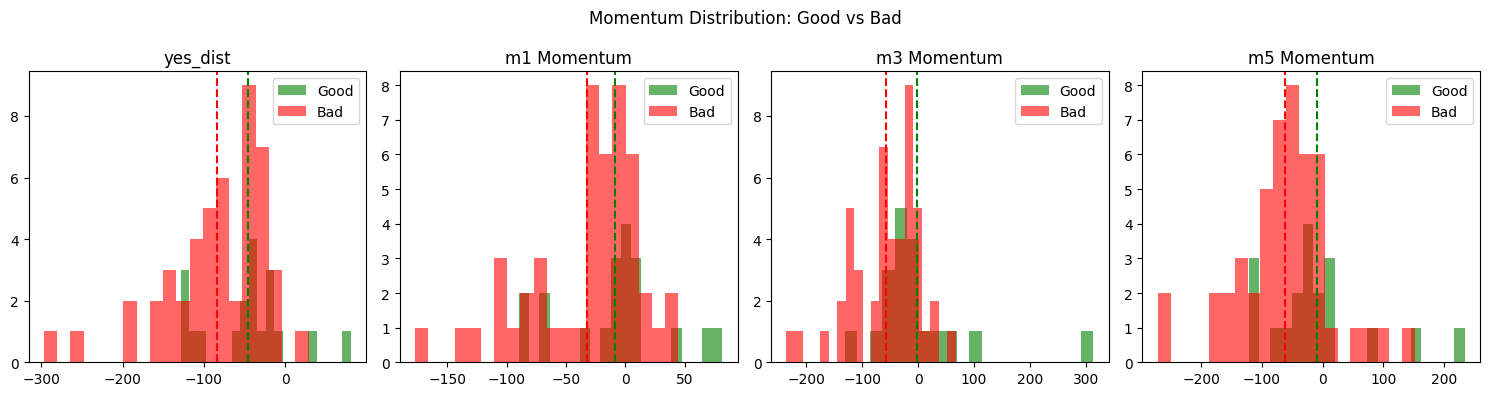

In [416]:
import matplotlib.pyplot as plt
import numpy as np

# good = comb_15[comb_15['reached_70'] == 1]
# bad = comb_15[comb_15['reached_70'] == 0]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# yes_dist
axes[0].hist(good['yes_dist'], bins=20, alpha=0.6, label='Good', color='green')
axes[0].hist(bad['yes_dist'], bins=20, alpha=0.6, label='Bad', color='red')
axes[0].axvline(good['yes_dist'].mean(), color='green', linestyle='--')
axes[0].axvline(bad['yes_dist'].mean(), color='red', linestyle='--')
axes[0].set_title('yes_dist')
axes[0].legend()

# 1m momentum
axes[1].hist(good['m1_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[1].hist(bad['m1_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[1].axvline(good['m1_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[1].axvline(bad['m1_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[1].set_title('m1 Momentum')
axes[1].legend()

# 3m momentum
axes[2].hist(good['m3_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[2].hist(bad['m3_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[2].axvline(good['m3_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[2].axvline(bad['m3_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[2].set_title('m3 Momentum')
axes[2].legend()

# 5m momentum
axes[3].hist(good['m5_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[3].hist(bad['m5_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[3].axvline(good['m5_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[3].axvline(bad['m5_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[3].set_title('m5 Momentum')
axes[3].legend()

plt.suptitle('Momentum Distribution: Good vs Bad')
plt.tight_layout()
plt.show()

In [417]:
# testing

from scipy.stats import norm
import numpy as np

# ===== 1. Extract parameters from your data =====

params = {
    'period': {
        'good': (0.4138,),
        'bad': (0.5862,)
    },
    'm1_yes_dist_momentum': {
        'good': (-17.5070, 51.8947),
        'bad':  (-19.7738, 48.4898)
    },
    'm3_yes_dist_momentum': {
        'good': (-29.0380, 82.5982),
        'bad':  (-32.8337, 73.5574)
    },
    'm5_yes_dist_momentum': {
        'good': (-31.1500, 93.6206),
        'bad':  (-37.5775, 85.6289)
    },
    'yes_dist': {
        'good': (-19.9004, 29.5222),
        'bad':  (-22.8592, 38.3313)
    },
}


# ===== 2. Prediction function =====
def predict(momentum_1m, momentum_3m, momentum_5m, yes_dist):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        'm1_yes_dist_momentum': momentum_1m,
        'm3_yes_dist_momentum': momentum_3m,
        # 'm5_yes_dist_momentum': momentum_5m,
        'yes_dist': yes_dist
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob


# ===== 3. Test cases ====

p1 = predict(
    momentum_1m = -26.09,    
    momentum_3m = -88.07,     
    momentum_5m = 0,    
    yes_dist = -39.74      
)
print(f"P(Good): {p1:.1%}")

P(Good): 40.7%


In [418]:
# export model

def write_model_to_json(parameters: dict, filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    params_serializable = {}
    for feature, values in parameters.items():
        params_serializable[feature] = {
            'good': list(values['good']),
            'bad': list(values['bad'])
        }
    
    with open(filepath, 'w') as f:
        json.dump(params_serializable, f, indent=2)
    
    print(f"Model saved to {filepath}")


def load_model_from_json(filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    with open(filepath, 'r') as f:
        params_serializable = json.load(f)
    
    # Convert lists back to tuples
    parameters = {}
    for feature, values in params_serializable.items():
        parameters[feature] = {
            'good': tuple(values['good']),
            'bad': tuple(values['bad'])
        }
    
    return parameters


# Correct dict syntax
# params = {
#     'period': {
#         'good': (0.4138,),
#         'bad': (0.5862,)
#     },
#     'm1_yes_dist_momentum': {
#         'good': (-17.5070, 51.8947),
#         'bad':  (-19.7738, 48.4898)
#     },
#     'm3_yes_dist_momentum': {
#         'good': (-29.0380, 82.5982),
#         'bad':  (-32.8337, 73.5574)
#     },
#     'm5_yes_dist_momentum': {
#         'good': (-31.1500, 93.6206),
#         'bad':  (-37.5775, 85.6289)
#     },
#     'yes_dist': {
#         'good': (-19.9004, 29.5222),
#         'bad':  (-22.8592, 38.3313)
#     },
# }

# Write
write_model_to_json(params)

# Read back
loaded = load_model_from_json()
print(loaded['m3_yes_dist_momentum']['good'])  # (-104.941, 95.989)

Model saved to /Users/yingxie/Documents/Git/Quant/Kalshi/btc_15_strategy/models/yes_bayesian.json
(-29.038, 82.5982)


In [441]:
# hour research
reached_list = [50,60,70,90]
time_dict = {str(x): 0 for x in range(24)}
test_df = comb_10
test_entry_price = 10

for hour in range(24):
    for reached in reached_list:
        df_h = test_df[test_df['hour'] == hour]
        if len(df_h) < 2:
            continue
        rate = df_h['reached_' + str(reached)].mean()
        ev = rate * ((reached - test_entry_price) / 100)  - (1-rate) * test_entry_price / 100
        time_dict[str(hour)] += ev

sorted_items = sorted(time_dict.items(), key=lambda x: x[1], reverse=True)
for key, item in sorted_items:
    print(f"Hour: {key}, EV: {item:.3f}")

Hour: 1, EV: 0.750
Hour: 6, EV: 0.629
Hour: 10, EV: 0.410
Hour: 11, EV: 0.400
Hour: 9, EV: 0.100
Hour: 2, EV: 0.092
Hour: 15, EV: 0.015
Hour: 0, EV: 0.000
Hour: 18, EV: 0.000
Hour: 19, EV: 0.000
Hour: 20, EV: 0.000
Hour: 21, EV: 0.000
Hour: 22, EV: 0.000
Hour: 23, EV: 0.000
Hour: 7, EV: -0.082
Hour: 4, EV: -0.087
Hour: 13, EV: -0.115
Hour: 5, EV: -0.161
Hour: 3, EV: -0.271
Hour: 8, EV: -0.287
Hour: 14, EV: -0.300
Hour: 16, EV: -0.321
Hour: 17, EV: -0.350
Hour: 12, EV: -0.400


In [442]:
# start research
trade_hour = [6,7,8,9,10,11,13,17]
reached_dict = {str(x): 0 for x in reached_list}
for hour in trade_hour:
    for reached in reached_list:
        df_h = test_df[test_df['hour'] == hour]
        if len(df_h) < 5:
            continue
        rate = df_h['reached_' + str(reached)].mean()
        ev = rate * ((reached - test_entry_price)/100 - 0.1)  - (1-rate) * test_entry_price / 100
        reached_dict[str(reached)] += ev

for key, item in reached_dict.items():
    print(f"Reached: {key}, EV: {item:.3f}")

Reached: 50, EV: -0.082
Reached: 60, EV: -0.029
Reached: 70, EV: 0.125
Reached: 90, EV: 0.091


In [454]:
# final hour research
trade_hour = [6,7,8,9,10,11,13,17]
for hour in trade_hour:
    df_h = test_df[test_df['hour'] == hour]
    if len(df_h) < 5:
        continue
    rate = df_h['reached_50'].mean()
    ev = rate * (0.5 - 0.1)  - (1-rate) * 0.10
    print(f"{hour:02d}:00 {len(df_h):3d} trades win {rate:.0%} | EV {ev:.2f}")

06:00  14 trades win 43% | EV 0.11
07:00  17 trades win 12% | EV -0.04
08:00  16 trades win 6% | EV -0.07
09:00   9 trades win 22% | EV 0.01
10:00  10 trades win 30% | EV 0.05
11:00   9 trades win 33% | EV 0.07
13:00  13 trades win 23% | EV 0.02
17:00  10 trades win 10% | EV -0.05


In [444]:
comb_10

,open,high,low,close,tick_count,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar,yes_dist,log_return,m3_log_return,m5_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,m1_yes_dist_momentum,m3_yes_dist_momentum,m5_yes_dist_momentum,time_decay,hour,minute,yes_spread,volume_surge,oi_change,subsequent_high,subsequent_low,reached_30,reached_40,reached_50,reached_60,reached_70,reached_90
0,80738.50,80738.62,80704.02,80704.68,51,KXBTC15M-26MAY110315-15,80850.20,22960.45,81148.14,0.110,0.110,0.069,0.077,0.100,0.100,0.067,0.074,0.926,0.900,0.933,0.900,0.923,0.890,0.931,0.890,-145.52,-5.652349e-04,0.000228,0.000336,80738.443333,80755.106,-0.138227,-0.117618,-0.179987,-45.63,-75.42,-141.75,9,2,6,0.003,1.143347,17035.97,0.550,0.001,1,1,1,0,0,0
1,80778.71,80778.71,80778.71,80778.71,0,KXBTC15M-26MAY110330-30,80762.06,41467.85,80132.91,0.180,0.210,0.010,0.019,0.170,0.190,0.006,0.011,0.989,0.810,0.994,0.830,0.981,0.790,0.990,0.820,16.65,8.628883e-05,0.000037,0.000067,80770.553333,80765.602,0.010516,0.004386,0.020616,6.97,22.09,18.89,1,2,29,0.008,1.469259,11822.27,0.013,0.001,0,0,0,0,0,0
2,80660.10,80660.10,80649.02,80649.02,0,KXBTC15M-26MAY110415-15,80727.64,29436.91,51913.33,0.110,0.120,0.053,0.089,0.100,0.100,0.050,0.088,0.912,0.900,0.950,0.900,0.911,0.880,0.947,0.890,-78.62,-1.106654e-03,0.000646,0.000539,80708.666667,80715.136,-0.023503,-0.015489,-0.097389,-89.30,-87.45,-70.97,4,3,11,0.001,0.994771,3765.10,0.770,0.004,1,1,1,1,1,0
3,80707.87,80707.87,80655.48,80671.19,43,KXBTC15M-26MAY110430-30,80727.56,70248.54,66265.76,0.270,0.270,0.005,0.005,0.260,0.260,0.003,0.004,0.996,0.740,0.997,0.740,0.995,0.730,0.995,0.730,-56.37,-1.060411e-03,0.000621,0.000496,80728.183333,80738.908,0.000772,0.014057,-0.069827,-85.59,-83.30,-72.75,1,3,29,0.001,2.060975,12913.93,0.004,0.001,0,0,0,0,0,0
4,80783.51,80783.51,80783.07,80783.07,0,KXBTC15M-26MAY110500-00,80822.75,19317.42,57375.53,0.150,0.150,0.054,0.066,0.140,0.140,0.050,0.061,0.939,0.860,0.950,0.860,0.934,0.850,0.946,0.850,-39.68,-3.774831e-04,0.000218,0.000166,80803.403333,80807.762,-0.023937,-0.018544,-0.049095,-30.50,-30.53,-32.32,3,3,57,0.005,1.152445,6650.92,0.089,0.001,0,0,0,0,0,0
5,80876.84,80876.84,80876.84,80876.84,0,KXBTC15M-26MAY110545-45,80907.03,19740.85,57125.30,0.190,0.200,0.051,0.120,0.180,0.190,0.040,0.110,0.890,0.810,0.960,0.820,0.880,0.800,0.949,0.810,-30.19,7.876483e-05,0.000083,0.000063,80873.450000,80875.244,-0.041504,-0.039287,-0.037314,6.37,-2.90,0.71,5,4,40,0.010,2.437241,11510.59,0.990,0.045,1,1,1,1,1,1
6,81085.62,81086.92,81084.40,81084.87,18,KXBTC15M-26MAY110645-45,81174.10,10313.42,55041.32,0.130,0.140,0.074,0.074,0.120,0.130,0.071,0.071,0.929,0.870,0.929,0.880,0.926,0.860,0.926,0.870,-89.23,-3.946474e-06,0.000625,0.000704,81088.310000,81127.988,-0.105686,-0.056806,-0.109924,-0.32,-102.47,-34.64,8,5,37,0.003,0.637187,6524.95,0.080,0.001,0,0,0,0,0,0
7,81037.17,81037.17,81023.00,81028.17,10,KXBTC15M-26MAY110700-00,81063.03,20127.38,43386.83,0.200,0.200,0.080,0.120,0.190,0.190,0.076,0.100,0.900,0.810,0.924,0.810,0.880,0.800,0.920,0.800,-34.86,-3.013313e-04,0.000207,0.000310,81055.270000,81065.842,-0.009573,0.003469,-0.043004,-24.42,-57.04,-19.85,4,5,56,0.020,1.785805,6077.88,0.170,0.001,0,0,0,0,0,0
8,80947.78,80978.61,80896.11,80978.61,57,KXBTC15M-26MAY110715-15,80947.47,64001.96,60275.88,0.500,0.840,0.057,0.800,0.490,0.830,0.050,0.790,0.210,0.170,0.950,0.510,0.200,0.160,0.943,0.500,31.14,1.481884e-05,0.000149,0.000266,80984.746667,80982.962,0.046050,0.043846,0.038469,1.20,-20.94,17.59,2,6,13,0.010,2.971757,-10886.70,0.990,0.690,1,1,1,1,1,1
9,81125.92,81125.92,81125.92,81125.92,0,KXBTC15M-26MAY110815-15,81176.19,14499.81,94435.85,0.130,0.130,0.027,0.027,0.120,0.

In [469]:
comb_15['reached_70'].mean()

0.025